### Step 1: Download the Dataset from S3

We are using Amazon S3 to store our dataset. In this step, we download the dataset from the S3 bucket and load it into a pandas DataFrame for further analysis.

- Bucket: `evangadi-ai`
- File Key: `original.csv`


In [3]:
import pandas as pd

# bucket_name = 'evangadi-ai'
# file_key = 'dataset.csv'
local_file = '../dataset/diabetes.csv' 

# s3 = boto3.client('s3')
# s3.download_file(bucket_name, file_key, local_file)

df = pd.read_csv(local_file)

df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
              'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df.head()



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Step 2: Describe the Dataset (Summary Statistics)

Before cleaning the data, we want to explore it.

Using `.describe()`, we can check:
- Minimum and maximum values
- Mean and standard deviation
- 25%, 50%, 75% percentiles

This helps us quickly detect unexpected values, like 0 in `Glucose` or `BMI`, and gives us candidate replacement values like mean or median.


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Step 3: Identify Missing or Invalid Values

In this dataset, some features like `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` should never be zero — but they are not technically missing (`NaN`), they’re just **invalid**.

We’ll:
- Check for `NaN` values using `.isnull()`
- Count how many zero values appear in medically critical columns

These zero values need to be handled in the next step.


In [5]:
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\nZero values (invalid) in critical columns:")

for col in invalid_zero_cols:
    count = (df[col] == 0).sum()
    print(f"{col}: {count}\n")



Zero values (invalid) in critical columns:
Glucose: 5

BloodPressure: 35

SkinThickness: 227

Insulin: 374

BMI: 11



### Step 4: we can replace Replace Invalid Zero Values with Median or remove the invalid values

Zero is not a valid value for features like `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`.
beacuse of our dataset is small removing will affect our dataset size so We will replace these invalid zero entries with the **median** of each column (excluding the zero values when calculating the median), because:
- Median is more robust to outliers than mean
- It better reflects the typical value of the column
we also create new binary columns like:
- `Glucose_missing`
- `Insulin_missing`
These flag whether the value was replaced. This allows our model to:
- Adjust its confidence in these features
- Learn different weights for true vs. imputed values

In [6]:
print("\n🔧 Replacing invalid zeros and flagging imputed rows:\n")
for col in invalid_zero_cols:
    median_val = df[df[col] != 0][col].median()
    
    # Create a new column to flag which rows are missing (had 0 before)
    flag_col = col + '_missing'
    df[flag_col] = (df[col] == 0).astype(int)
    # printing
    zero_count = (df[col] == 0).sum()   
    print(f"Replacing {zero_count} zeros in '{col}' with median: {median_val}")
    # Replace the zeros with median
    df[col] = df[col].replace(0, median_val)




🔧 Replacing invalid zeros and flagging imputed rows:

Replacing 5 zeros in 'Glucose' with median: 117.0
Replacing 35 zeros in 'BloodPressure' with median: 72.0
Replacing 227 zeros in 'SkinThickness' with median: 29.0
Replacing 374 zeros in 'Insulin' with median: 125.0
Replacing 11 zeros in 'BMI' with median: 32.3


### verifying

In [7]:
df.describe()
# df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_missing,BloodPressure_missing,SkinThickness_missing,Insulin_missing,BMI_missing
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958,0.006510,0.045573,0.295573,0.486979,0.014323
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951,0.080476,0.208693,0.456597,0.500156,0.118896
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Step 5: Visual Check of Feature Distributions 

Now that invalid values have been fixed, we’ll:
- Plot histograms for all columns to see their distributions
- Specifically check if any features are highly skewed
- Confirm that the target label `Outcome` has a reasonable class balance (not heavily biased)

This helps guide later decisions like normalization, feature engineering, or SMOTE (if needed).


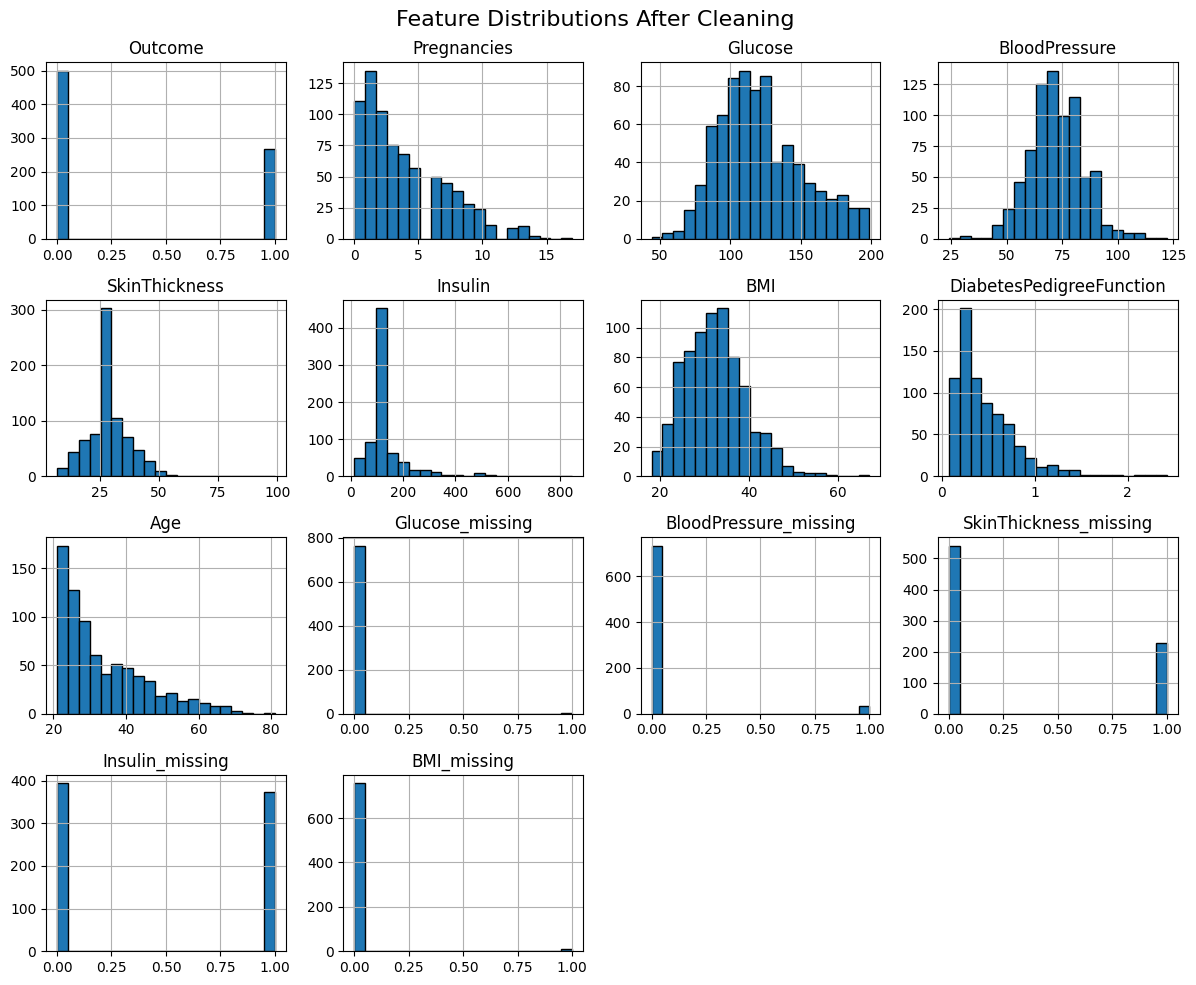

In [13]:
import matplotlib.pyplot as plt

# Plot all numeric feature distributions
df.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle("Feature Distributions After Cleaning", fontsize=16)
plt.tight_layout()
plt.show()


### Step 6a: Checking statistics of Insulin and BMI

We will look at:
- Mean, median, min, max, standard deviation
- Skewness of the distributions
This helps us decide if a transformation (like log) is necessary.


In [14]:
from scipy.stats import skew

# Calculate skewness
insulin_skew = skew(df['Insulin'])
bmi_skew = skew(df['BMI'])
print(f"\nSkewness:\nInsulin: {insulin_skew:.2f}\nBMI: {bmi_skew:.2f}")



Skewness:
Insulin: 3.37
BMI: 0.60


### Step 7: Move Target Column to Front

SageMaker's XGBoost expects the label column (here, 'Outcome') to be the **first column** in the dataset.

We will move the 'Outcome' column from its current position to the front.


In [15]:
cols = df.columns.tolist()

# Remove 'Outcome' and insert at position 0
cols.insert(0, cols.pop(cols.index('Outcome')))
df = df[cols]
df.head()


,Outcome,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_missing,BloodPressure_missing,SkinThickness_missing,Insulin_missing,BMI_missing
0,1,6,148,72,35,125,33.6,0.627,50,0,0,0,1,0
1,0,1,85,66,29,125,26.6,0.351,31,0,0,0,1,0
2,1,8,183,64,29,125,23.3,0.672,32,0,0,1,1,0
3,0,1,89,66,23,94,28.1,0.167,21,0,0,0,0,0
4,1,0,137,40,35,168,43.1,2.288,33,0,0,0,0,0


### Step 8: Split Dataset into Training and Validation Sets

To train and evaluate the model, we split the cleaned dataset into:

- **Training set** (e.g., 80%)
- **Validation set** (e.g., 20%)

We will then save both files without headers or indexes.


In [16]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Outcome'])

# Save both files without header and index
train_df.to_csv('../dataset/clean/diabetes/train.csv', index=False, header=False)
val_df.to_csv('../dataset/clean/diabetes/validation.csv', index=False, header=False)


### Step 9: Upload Training and Validation Files to S3

Now that we've split the dataset, we upload both files to your S3 bucket.

We'll use `boto3` to upload:
- `train_final.csv` → `s3://evangadi-ai/train/train.csv`
- `validation_final.csv` → `s3://evangadi-ai/test/test.csv`


In [17]:
import boto3

# S3 setup
bucket_name = 'evangadi-ai'
train_key = 'train/diabet_train.csv'
val_key = 'test/diabet_test.csv'

s3 = boto3.resource('s3')

s3.Bucket(bucket_name).upload_file('../dataset/clean/diabetes/train.csv', train_key)
s3.Bucket(bucket_name).upload_file('../dataset/clean/diabetes/validation.csv', val_key)

print("✅ Files uploaded successfully.")

KeyboardInterrupt: 

### we have finished the data prepairing and trating step next we will train the model using xg-boost model

 ## ✅ Phase 2: Local Training Job Execution

In this step, we define and run a local SageMaker XGBoost training job using the `Estimator` class.

- LocalSession is used to avoid using real AWS resources.
- Docker runs the training job with local `train.csv` and `validation.csv` data.
- The trained model is saved in `local_output/.../model.tar.gz`.

### Key Tools
- `sagemaker.local.LocalSession`: Enables local training
- `sagemaker.image_uris.retrieve`: Gets the correct XGBoost container
- `Estimator`: SageMaker class to run the training logic


In [10]:
# train_model_cloud.py

import sagemaker
from sagemaker.inputs import TrainingInput
from sagemaker.estimator import Estimator
import boto3
import os

# 1. Create SageMaker session and IAM role
session = sagemaker.Session()
role = "arn:aws:iam::200110254389:role/service-role/AmazonSageMaker-ExecutionRole-20250702T122723"

# 2. Define S3 input paths
bucket = 'evangadi-ai'

train_input = TrainingInput(f's3://{bucket}/test/diabet_test.csv', content_type='text/csv')
val_input = TrainingInput(f's3://{bucket}/train/diabet_train.csv', content_type='text/csv')

# 3. Get XGBoost container image URI
container = sagemaker.image_uris.retrieve("xgboost", region="us-east-1", version="1.5-1")

# 4. Create XGBoost Estimator (Cloud Mode)
xgb_estimator = Estimator(
    image_uri=container,
    role=role,
    instance_count=1,
    instance_type='ml.m5.large',  # You can change to 'ml.t2.medium' for Free Tier
    output_path=f's3://{bucket}/output',
    sagemaker_session=session
)

# 5. Set hyperparameters
xgb_estimator.set_hyperparameters(
    objective="binary:logistic",
    num_round=100,
    max_depth=5,
    eta=0.2,
    gamma=4,
    min_child_weight=6,
    subsample=0.8,
    verbosity=1
)

# 6. Launch training job in the cloud
xgb_estimator.fit({'train': train_input, 'validation': val_input})


INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2025-07-11-04-35-16-117


2025-07-11 04:35:33 Starting - Starting the training job.

### Find your trained model path


In [ ]:
model_path = xgb_estimator.model_data
print(model_path)

Download the model locally

In [12]:
import boto3
import tarfile
import os

# 1. Download the model tar.gz file
s3 = boto3.client('s3')
bucket_name = 'evangadi-ai'  
key = 'output/sagemaker-xgboost-2025-07-11-04-29-11-878/output/model.tar.gz'  

local_model_path = '../model/model.tar.gz'

s3.download_file(bucket_name, key, local_model_path)

# 2. Extract the model.tar.gz
with tarfile.open(local_model_path) as tar:
    tar.extractall(path='model')


## we downlode the trained model after this step we will test it


In [37]:
import xgboost as xgb

model = xgb.Booster()
model.load_model("../model/diabet-xgboost-model")


 Check precision or accuracy of model
If you already evaluated your model during training, it won't be shown unless you:

Used a custom script mode, or

Set eval_metric and captured logs.

Since you're using built-in XGBoost in SageMaker, you can’t get precision directly unless you:

Use a script-based training job, or

Re-evaluate locally.

So, here's how to do it locally:



In [31]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
import numpy as np



# Load the validation CSV without headers
df = pd.read_csv("./../dataset/clean/diabetes/validation.csv", header=None)

# First column is label
y_test = df.iloc[:, 0]
X_test = df.iloc[:, 1:]

# Convert DataFrame to DMatrix
dtest = xgb.DMatrix(X_test)

# Make predictions
y_pred_proba = model.predict(dtest)
y_pred = np.round(y_pred_proba)  # Round probabilities to get binary prediction

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)

print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")

# Optional: Show label distribution
print("Label distribution in predictions:", pd.Series(y_pred).value_counts())
print("Label distribution in actual data:", y_test.value_counts())


Accuracy: 83.77 %
Precision: 80.85 %
Label distribution in predictions: 0.0    107
1.0     47
Name: count, dtype: int64
Label distribution in actual data: 0
0    100
1     54
Name: count, dtype: int64


## testing with a random number

In [64]:

import pandas as pd


# Create one test data point (replace values as needed)
input_data = pd.DataFrame([{
    "Pregnancies": 4,
    "Glucose": 149,
    "BloodPressure": 2,
    "SkinThickness": 22,
    "Insulin": 45,
    "BMI": 24.7,
    "DiabetesPedigreeFunction": 5,
    "Age": 55,
    "k":0,
    "l":0,
    "m":0,
    "uuu":0,
    "lw":0,
}])
# 1,9,184,85,15,125,30.0,1.213,49,0,0,0,1,0
# 0,4,94,65,22,125,24.7,0.148,21,0,0,0,1,0

# Convert to DMatrix and predict
dmatrix = xgb.DMatrix(input_data)
prediction = model.predict(dmatrix)

# Interpret result
label = int(prediction[0] >= 0.5)
print("Predicted Label:", label)
print("Probability:", float(prediction[0]))


Predicted Label: 1
Probability: 0.6977241635322571
